## **Analysis & Visualization**

In [1]:
import pandas as pd
import sys
sys.path.append("..")

from src.analysis import add_basic_location_stats

In [2]:
df_ner = pd.read_pickle("../data/processed/df_ner3.pkl")
df_analysis = add_basic_location_stats(df_ner)

df_analysis["locations"].head(10)

12278    [Pontarlier, Haut-Doubs, Haut-Doubs, de Besanç...
11189    [AUBE   , centrale nucléaire de Nogent, Centra...
13028    [Metz, Metz, Lorraine, circonscription de Metz...
14348    [Villeneuve-St-Georges, Entrepri-, Pays, la Fr...
14268    [Français, République française Jemenin le Pas...
8337     [Carvin Conseiller général, Union, PAS-DE-CALA...
16836    [Touraine, la France, Touraine, la France, SAI...
1130     [Lozère, Lozériens, France, Elus, Usine C A F,...
8350     [Conseiller Général, Régional, SAINT-OMER, Cir...
1138     [Etat, Etat, Etat, Etat, Etat, Etat, circonscr...
Name: locations, dtype: object

In [46]:
df_analysis.columns.tolist()

['id',
 'date',
 'subject',
 'title',
 'contexte-election',
 'contexte-tour',
 'cote',
 'departement',
 'departement-nom',
 'departement-insee',
 'identifiant de circonscription',
 'images',
 'pdf',
 'ocr_url',
 'titulaire-nom',
 'titulaire-prenom',
 'titulaire-sexe',
 'titulaire-age',
 'titulaire-age-calcule',
 'titulaire-age-tranche',
 'titulaire-profession',
 'titulaire-mandat-en-cours',
 'titulaire-mandat-passe',
 'titulaire-associations',
 'titulaire-autres-statuts',
 'titulaire-soutien',
 'titulaire-liste',
 'titulaire-decorations',
 'suppleant-nom',
 'suppleant-prenom',
 'suppleant-sexe',
 'suppleant-age',
 'suppleant-age-calcule',
 'suppleant-age-tranche',
 'suppleant-profession',
 'suppleant-mandat-en-cours',
 'suppleant-mandat-passe',
 'suppleant-associations',
 'suppleant-autres-statuts',
 'suppleant-soutien',
 'suppleant-liste',
 'suppleant-decorations',
 'zip_file',
 'text_file',
 'text',
 'text_clean',
 'locations',
 'n_locations',
 'locations_clean',
 'n_locations_clean'

In [4]:
from src.analysis import add_clean_locations

df_analysis = add_clean_locations(df_analysis)
df_analysis[["locations", "locations_clean"]].head(10)

,locations,locations_clean
12278,"[Pontarlier, Haut-Doubs, Haut-Doubs, de Besanç...","[Pontarlier, Haut-Doubs, Haut-Doubs, Besançon]"
11189,"[AUBE , centrale nucléaire de Nogent, Centra...","[AUBE, centrale nucléaire de Nogent, Centrale,..."
13028,"[Metz, Metz, Lorraine, circonscription de Metz...","[Metz, Metz, Lorraine, circonscription de Metz..."
14348,"[Villeneuve-St-Georges, Entrepri-, Pays, la Fr...","[Villeneuve-St-Georges, Entrepri-, Pays, Franc..."
14268,"[Français, République française Jemenin le Pas...","[République française Jemenin le Pas Voter, Se..."
8337,"[Carvin Conseiller général, Union, PAS-DE-CALA...","[Carvin Conseiller général, Union, PAS-DE-CALA..."
16836,"[Touraine, la France, Touraine, la France, SAI...","[Touraine, France, Touraine, France, SAINT-CYR..."
1130,"[Lozère, Lozériens, France, Elus, Usine C A F,...","[Lozère, Lozériens, France, Elus, Usine C A F,..."
8350,"[Conseiller Général, Régional, SAINT-OMER, Cir...","[Conseiller Général, Régional, SAINT-OMER, Cir..."
1138,"[Etat, Etat, Etat, Etat, Etat, Etat, circonscr...","[circonscription, LOIRE-ATLANTIQUE, circonscri..."


In [35]:
import pandas as pd

df = pd.read_pickle("../data/processed/df_spatial_analysis.pkl")
locations_ref = pd.read_csv("../data/processed/locations_reference.csv")

df[[
    "departement-nom",
    "locations_clean",
    "classified_locations",
    "local_ratio",
    "national_international_ratio",
    "unknown_ratio",
    "dominant_scale"
]].head(20)

,departement-nom,locations_clean,classified_locations,local_ratio,national_international_ratio,unknown_ratio,dominant_scale
2836,Val-de-Marne,[VIE],"[{'location': 'VIE', 'scale': 'unknown'}]",0.000000,0.000000,1.000000,unknown
2833,Val-de-Marne,"[Arcueil, Cachan, Gentilly Kremlin-Bicêtre, Villejuif, Croyez, Fiscalité, Hautes-Bruyères V, Krem-, Hôtel, Cachan, Arcueil, Arcueil, Candidat]","[{'location': 'Arcueil', 'scale': 'local'}, {'location': 'Cachan', 'scale': 'local'}, {'location': 'Gentilly Kremlin-Bicêtre', 'scale': 'unknown'}, {'location': 'Villejuif', 'scale': 'local'}, {'location': 'Croyez', 'scale': 'unknown'}, {'location': 'Fiscalité', 'scale': 'unknown'}, {'location': 'Hautes-Bruyères V', 'scale': 'unknown'}, {'location': 'Krem-', 'scale': 'unknown'}, {'location': 'Hôtel', 'scale': 'unknown'}, {'location': 'Cachan', 'scale': 'local'}, {'location': 'Arcueil', 'scale': 'local'}, {'location': 'Arcueil', 'scale': 'local'}, {'location': 'Candidat', 'scale': 'unknown'}]",0.461538,0.000000,0.538462,local
19562,Yonne,"[France, Pays, Avallon, VERGIGNY Chef, Conseiller Général]","[{'location': 'France', 'scale': 'national_international'}, {'location': 'Pays', 'scale': 'unknown'}, {'location': 'Avallon', 'scale': 'local'}, {'location': 'VERGIGNY Chef', 'scale': 'unknown'}, {'location': 'Conseiller Général', 'scale': 'local'}]",0.400000,0.200000,0.400000,local
10328,Paris,"[17e Circonscription, Palais Bourbon, Paris, Paris, France, France, France, Saint-Lam-, Paris Ancien Député, Paris Quartier St-Lambert, Ecol, XVe arrondissement, France]","[{'location': '17e Circonscription', 'scale': 'unknown'}, {'location': 'Palais Bourbon', 'scale': 'unknown'}, {'location': 'Paris', 'scale': 'local'}, {'location': 'Paris', 'scale': 'local'}, {'location': 'France', 'scale': 'national_international'}, {'location': 'France', 'scale': 'national_international'}, {'location': 'France', 'scale': 'national_international'}, {'location': 'Saint-Lam-', 'scale': 'unknown'}, {'location': 'Paris Ancien Député', 'scale': 'unknown'}, {'location': 'Paris Quartier St-Lambert', 'scale': 'unknown'}, {'location': 'Ecol', 'scale': 'unknown'}, {'location': 'XVe arrondissement', 'scale': 'unknown'}, {'location': 'France', 'scale': 'national_international'}]",0.153846,0.307692,0.538462,national_international
2626,Territoire-de-Belfort,"[Territoire de Belfort, Sermamagny Ancien A F N, Régions, France, l'Europe, France]","[{'location': 'Territoire de Belfort', 'scale': 'unknown'}, {'location': 'Sermamagny Ancien A F N', 'scale': 'unknown'}, {'location': 'Régions', 'scale': 'unknown'}, {'location': 'France', 'scale': 'national_international'}, {'location': 'l'Europe', 'scale': 'unknown'}, {'location': 'France', 'scale': 'national_international'}]",0.000000,0.333333,0.666667,national_international
13071,Nièvre,"[France, Europe, Europe, O P A, Schtroumpfs, Europe, Russie, France, Arrêter, Lac Tchad, Eureka, l'Europe, Ouest]","[{'location': 'France', 'scale': 'national_international'}, {'location': 'Europe', 'scale': 'national_international'}, {'location': 'Europe', 'scale': 'national_international'}, {'location': 'O P A', 'scale': 'unknown'}, {'location': 'Schtroumpfs', 'scale': 'unknown'}, {'location': 'Europe', 'scale': 'national_international'}, {'location': 'Russie', 'scale': 'unknown'}, {'location': 'France', 'scale': 'national_international'}, {'location': 'Arrêter', 'scale': 'unknown'}, {'location': 'Lac Tchad', 'scale': 'unknown'}, {'location': 'Eureka', 'scale': 'unknown'}, {'location': 'l'Europe', 'scale': 'unknown'}, {'location': 'Ouest', 'scale': 'unknown'}]",0.000000,0.384615,0.615385,national_international
17993,Pas-de-Calais,"[Barlin, Electrotechnicien, l'Europe, Maastricht, États-unis, Tiers-]","[{'location': 'Barlin', 'scale': 'local'}, {'location': 'Electrotechnicien', 'scale': 'unknown'}, {'location': 'l'Europe', 'scale': 'unknown'}, {'location': 'Maastricht', 'scale': 'unknown'}, {'location': 'États-unis', 'scale': 'national_international'}, {'locat

In [36]:
locations_ref[[
    "location",
    "country",
    "country_code",
    "county",
    "state",
    "display_name",
    "geo_class",
    "geo_type"
]].head(10)

,location,country,country_code,county,state,display_name,geo_class,geo_type
0,VIE,France,fr,Vendée,Pays de la Loire,"Vie, La Croix de Vie, Commequiers, Les Sables-d'Olonne, Vendée, Pays de la Loire, France métropolitaine, 85220, France",place,neighbourhood
1,Arcueil,France,fr,Val-de-Marne,Île-de-France,"Arcueil, L'Haÿ-les-Roses, Val-de-Marne, Île-de-France, France métropolitaine, 94110, France",boundary,administrative
2,Cachan,France,fr,Val-de-Marne,Île-de-France,"Cachan, L'Haÿ-les-Roses, Val-de-Marne, Île-de-France, France métropolitaine, 94230, France",boundary,administrative
3,Gentilly Kremlin-Bicêtre,France,fr,Val-de-Marne,Île-de-France,"Le Kremlin-Bicêtre, L'Haÿ-les-Roses, Val-de-Marne, Île-de-France, France métropolitaine, 94270, France",boundary,political
4,Villejuif,France,fr,Val-de-Marne,Île-de-France,"Villejuif, L'Haÿ-les-Roses, Val-de-Marne, Île-de-France, France métropolitaine, 94800, France",boundary,administrative
5,Croyez,France,fr,Rhône,Auvergne-Rhône-Alpes,"Croyez, Ville, Île des Pêcheurs, Condrieu, Lyon, Rhône, Auvergne-Rhône-Alpes, France métropolitaine, 69420, France",place,neighbourhood
6,Fiscalité,France,fr,Sarthe,Pays de la Loire,"Budget, Fiscalité, Dette et Trésorerie, Place Saint-Pierre, Cité Plantagenêt, Le Mans, Sarthe, Pays de la Loire, France métropolitaine, 72000, France",office,government
7,Hautes-Bruyères V,France,fr,Meurthe-et-Moselle,Grand Est,"Hautes Bruyères, Trondes, Toul, Meurthe-et-Moselle, Grand Est, France métropolitaine, 54570, France",place,locality
8,Krem-,France,fr,Pyrénées-Atlantiques,Nouvelle-Aquitaine,"Krem tattoo, Rue Émile Guichenné, Quartier du Hédas, Centre Ville, Pau, Pyrénées-Atlantiques, Nouvelle-Aquitaine, France métropolitaine, 64000, France",shop,tattoo
9,Hôtel,France,fr,Nord,Hauts-de-France,"Hôtel, Bachy, Lille, Nord, Hauts-de-France, France métropolitaine, 59830, France",place,hamlet


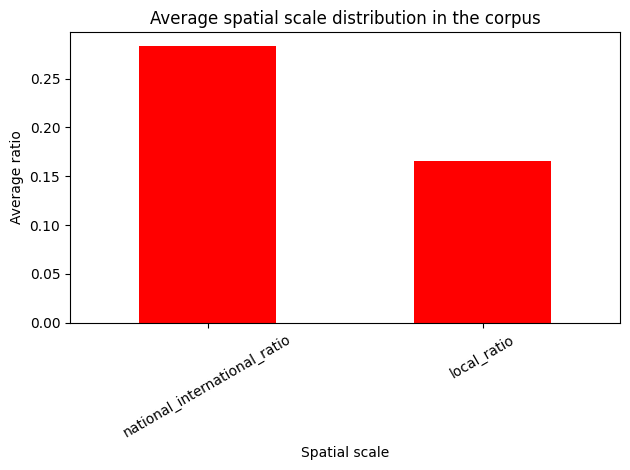

In [38]:
import matplotlib.pyplot as plt

scale_means = df[[
    "local_ratio",
    "national_international_ratio"
]].mean().sort_values(ascending=False)

scale_means.plot(kind="bar", color="red")

plt.title("Average spatial scale distribution in the corpus")
plt.ylabel("Average ratio")
plt.xlabel("Spatial scale")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

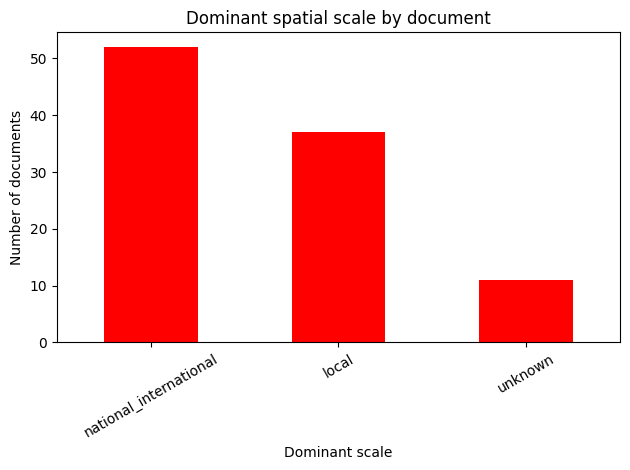

In [39]:
df["dominant_scale"].value_counts().plot(kind="bar", color="red")

plt.title("Dominant spatial scale by document")
plt.ylabel("Number of documents")
plt.xlabel("Dominant scale")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

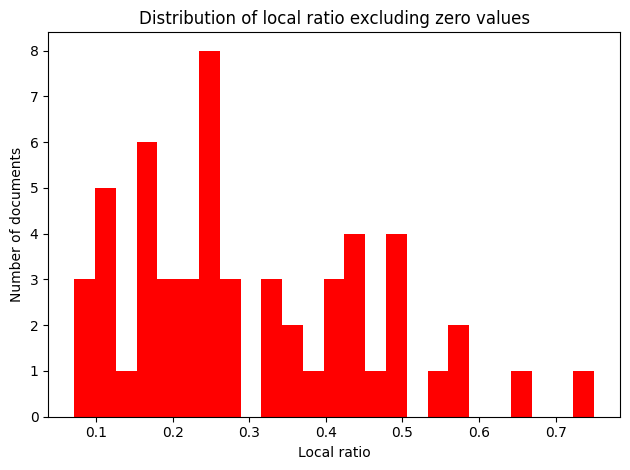

In [41]:
local_nonzero = df[df["local_ratio"] > 0]["local_ratio"]

local_nonzero.plot(kind="hist", bins=25, color="red")

plt.title("Distribution of local ratio excluding zero values")
plt.xlabel("Local ratio")
plt.ylabel("Number of documents")
plt.tight_layout()
plt.show()

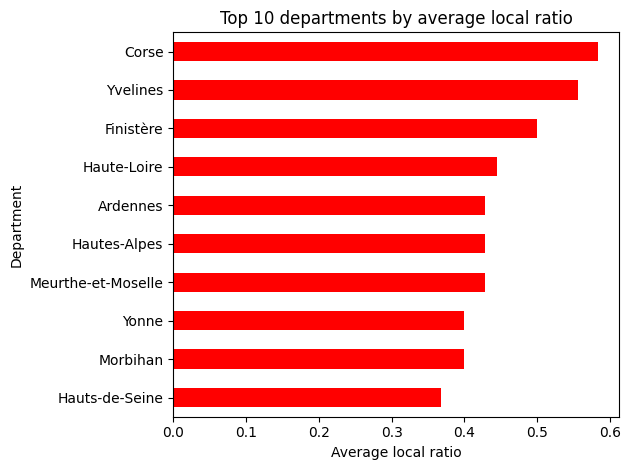

In [42]:
dept_local = (
    df.groupby("departement-nom")["local_ratio"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

dept_local.plot(kind="barh", color="red")

plt.title("Top 10 departments by average local ratio")
plt.xlabel("Average local ratio")
plt.ylabel("Department")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

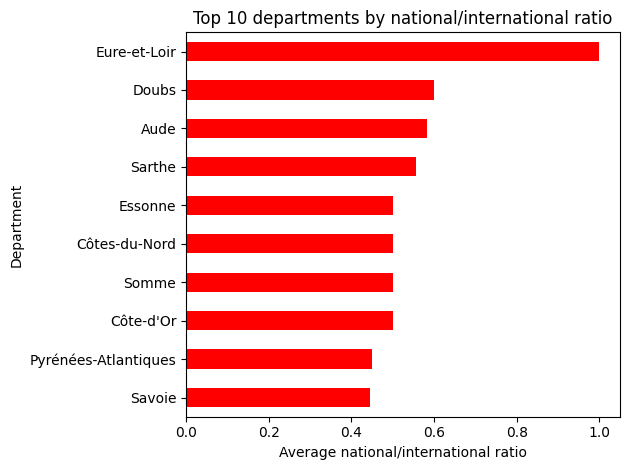

In [43]:
dept_nonlocal = (
    df.groupby("departement-nom")["national_international_ratio"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

dept_nonlocal.plot(kind="barh", color="red")

plt.title("Top 10 departments by national/international ratio")
plt.xlabel("Average national/international ratio")
plt.ylabel("Department")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

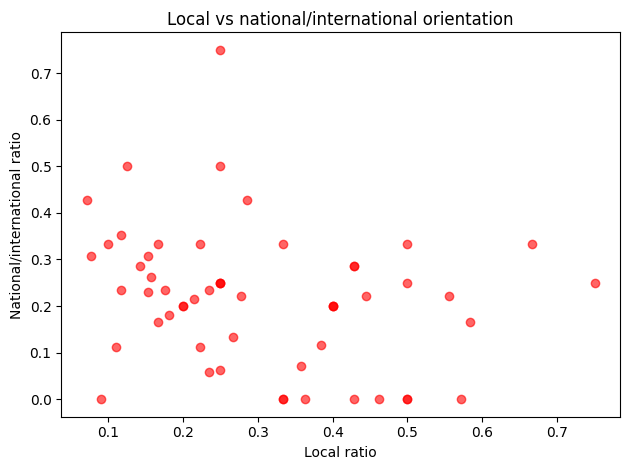

In [45]:
df_plot = df[df["local_ratio"] > 0]

plt.scatter(
    df_plot["local_ratio"],
    df_plot["national_international_ratio"],
    alpha=0.6,
    color="red"
)

plt.title("Local vs national/international orientation")
plt.xlabel("Local ratio")
plt.ylabel("National/international ratio")
plt.tight_layout()
plt.show()

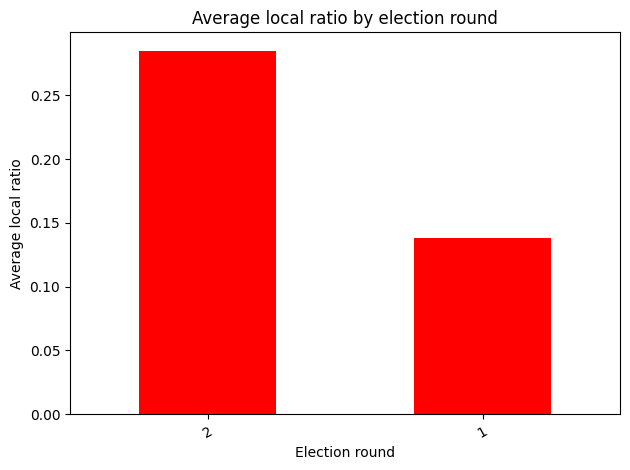

In [48]:
tour_local = (
    df.groupby("contexte-tour")["local_ratio"]
    .mean()
    .sort_values(ascending=False)
)

tour_local.plot(kind="bar", color="red")

plt.title("Average local ratio by election round")
plt.ylabel("Average local ratio")
plt.xlabel("Election round")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

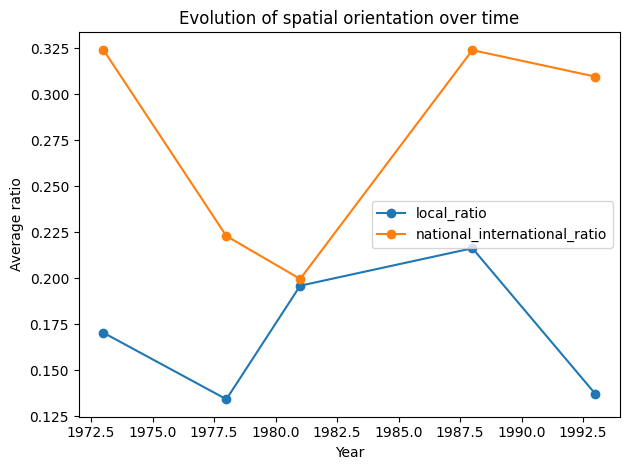

In [49]:
df["year"] = pd.to_datetime(df["date"], errors="coerce").dt.year

year_local = df.groupby("year")[
    ["local_ratio", "national_international_ratio"]
].mean()

year_local.plot(kind="line", marker="o")

plt.title("Evolution of spatial orientation over time")
plt.ylabel("Average ratio")
plt.xlabel("Year")
plt.tight_layout()
plt.show()